# Latent Dynamics Estimation on a Synthetic Generator
# 2.1. Synthetic generator on the two-sphere

In [108]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.spatial import procrustes
import pandas as pd

In [73]:
# Separate fixed seeds
latent_seed = 0
feature_seed = 1
noise_seed = 2

In [28]:
### Fixes:
# 1. Changed the number of samples to reach T, instead of having N=T
# 2. Corrected the initial stationary distribution
# 3. Allowed for arbitrary mu by creating new tangent space for each mu
# 4. Added checks to see if all paths Yt < pi, meaning they map uniquely through exp_mu(Yt)
# 5. Ensured that the values Xt all lie on S^2 
# 6. Added random seed for OU innovations


# Parameters
mu    = np.array([0,0,1])
kappa = 0.5
sigma = 0.2
dt    = 0.01
T     = 100
d     = 2

def simulate_ou_on_sphere(mu = np.array([0,0,1]),
                          kappa: float = 0.5,
                          sigma: float = 0.2,
                          dt:float = 0.01,
                          T: int = 100,
                          d: int = 2,
                          rand_seed=0):
    
    # random seed for OU innovations
    np.random.seed(rand_seed)
    
    # Number of samples required to reach T
    N = int(T/dt) + 1

    # Generating the latent process Yt
    Y = np.zeros(shape=(N,d))
    Y[0] = np.random.multivariate_normal(mean=np.zeros(d), cov=(sigma**2/(2*kappa)) * np.eye(d))

    ou_std = np.sqrt((sigma**2 / (2*kappa)) * (1 - np.exp(-2*kappa*dt)))

    for t in range(1,N):
        xi = np.random.multivariate_normal(mean=np.zeros(d), cov=(np.eye(d)))
        Y[t] = np.exp(-kappa * dt) * Y[t-1] + ou_std * xi


    # ensure mu is unit
    mu = np.asarray(mu, dtype=float)
    mu = mu / np.linalg.norm(mu)

    # build orthonormal tangent basis u1,u2
    if abs(mu[2]) < 0.9:
        ref = np.array([0.0, 0.0, 1.0])
    else:
        ref = np.array([0.0, 1.0, 0.0])
    u1 = np.cross(ref, mu)
    u1 /= np.linalg.norm(u1)
    u2 = np.cross(mu, u1)  # already unit

    # map tangent coordinates Y (shape (N,2)) to R^3
    Y_norm = np.linalg.norm(Y, axis=1)
    sinc = np.divide(np.sin(Y_norm), Y_norm, where=Y_norm!=0, out=np.ones_like(Y_norm))
    tangent = (Y[:, 0][:, None] * u1[None, :]) + (Y[:, 1][:, None] * u2[None, :])
    X = np.cos(Y_norm)[:, None] * mu[None, :] + (sinc[:, None] * tangent)

    # Checks
    max_r = np.max(np.linalg.norm(Y, axis=1))
    X_norms = np.linalg.norm(X, axis=1)

    print("max ||Y_t|| =", max_r)
    print("max | ||X_t|| - 1 | =", np.max(np.abs(X_norms - 1)))

    assert max_r < np.pi
    assert np.allclose(X_norms, 1.0)
    
    return X, Y

X, Y = simulate_ou_on_sphere(rand_seed=latent_seed)


max ||Y_t|| = 0.44720805870482355
max | ||X_t|| - 1 | = 1.1102230246251565e-16


Both assert statements passed, this validates the function

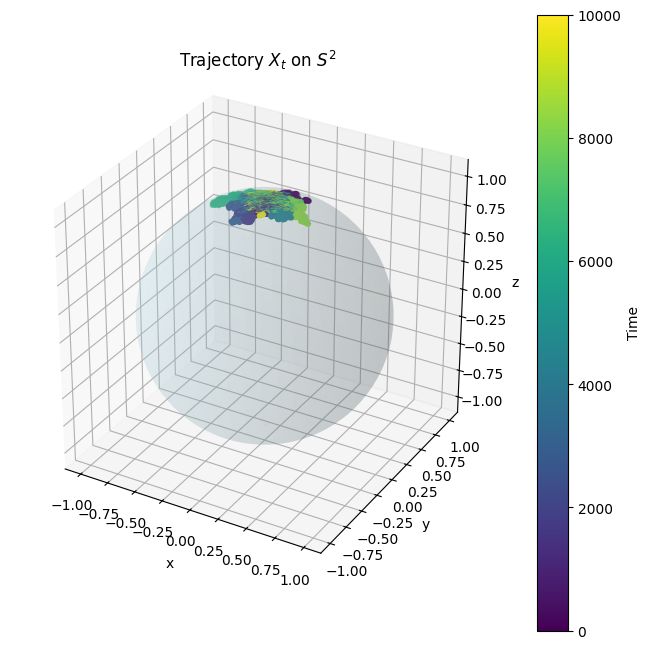

In [40]:
### Fixes
# 1. Now the axes all have the same aspect ratio
# 2. I have plotted a translucent unit sphere in the same figure
# 3. The points are coloured based on their time index
# 4. The axes labels have been corrected



fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# sphere
u = np.linspace(0, 2*np.pi, 100)
v = np.linspace(0, np.pi, 100)

xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones_like(u), np.cos(v))

ax.plot_surface(
    xs, ys, zs,
    alpha=0.15,
    color='lightblue',
    linewidth=0
)

# trajectory coloured by time
t = np.arange(len(X))

sc = ax.scatter(
    X[:,0],
    X[:,1],
    X[:,2],
    c=t,
    cmap='viridis',
    s=8
)

fig.colorbar(sc, ax=ax, label='Time')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title(r'Trajectory $X_t$ on $S^2$')

ax.set_box_aspect([1,1,1])

plt.show()

### Different subsets of data for different purposes <span style="color:green">(NEW)

In [103]:
burnin = 500
n_ou = 2000
n_val = 2000
gap = 10

X_geom = X[burnin::gap]
Y_geom = Y[burnin::gap]

X_ou = X[burnin:burnin+n_ou]
Y_ou = Y[burnin:burnin+n_ou]

X_val = X[burnin+n_ou:burnin+n_ou+n_val]
Y_val = Y[burnin+n_ou:burnin+n_ou+n_val]

The effective sampling interval of `X_geom` and `Y_geom` is now $\Delta t_\text{new} = 10 \Delta t = 0.1$

# 2.2.  Construction of the noisy high-dimensional observation

In [104]:
def draw_feature_map(input_dim=3, D=50, seed=0):
    rng = np.random.default_rng(seed)

    W = rng.multivariate_normal(
        mean=np.zeros(input_dim),
        cov=np.eye(input_dim),
        size=D
    )

    b = rng.uniform(0, 2*np.pi, size=D)

    return W, b


def apply_feature_map(X, W, b):
    Gclean = np.cos(X @ W.T + b)
    return Gclean

def embed_with_noise(X, W, b, D, eta, sigma_eta):
    # Crop the arrays if needed
    W = W[:D, :]
    b = b[:D]
    eta = eta[:, :D]

    # Apply the feature map
    Gclean = apply_feature_map(X, W, b)

    # Add observation noise to Gclean
    Z = Gclean + sigma_eta * eta

    res = {
        "Gclean": Gclean,
        "Zobs": Z,
        "W": W,
        "b": b,
        "D": D,
        "sigma_eta": sigma_eta
    }

    return res

### Drawing all random variables once
Using $D=100$ to produce these vectors so that I can crop down for $D=50$ without having to regenerate variables

In [105]:
# robustness grid
sigma_etas = [0, 0.05, 0.1, 0.2]
Ds = [50, 100]

# Timesteps
N = X_geom.shape[0]

# Draw feature map once
W, b = draw_feature_map(input_dim=3, D=Ds[1], seed=feature_seed)

# Draw one standard-normal noise matrix once
rng_noise = np.random.default_rng(noise_seed)
eta = rng_noise.normal(0.0, 1.0, size=(N,Ds[1]))

In [ ]:
# Reuse same noise_base for all noise levels
obs_dict_00 = embed_with_noise(X_geom, W, b, Ds[0], eta, sigma_etas[0])
obs_dict_10 = embed_with_noise(X_geom, W, b, Ds[0], eta, sigma_etas[1])
obs_dict_20 = embed_with_noise(X_geom, W, b, Ds[0], eta, sigma_etas[2])
obs_dict_30 = embed_with_noise(X_geom, W, b, Ds[0], eta, sigma_etas[3])

obs_dict_01 = embed_with_noise(X_geom, W, b, Ds[1], eta, sigma_etas[0])
obs_dict_11 = embed_with_noise(X_geom, W, b, Ds[1], eta, sigma_etas[1])
obs_dict_21 = embed_with_noise(X_geom, W, b, Ds[1], eta, sigma_etas[2])
obs_dict_31 = embed_with_noise(X_geom, W, b, Ds[1], eta, sigma_etas[3])

### Showing that the first three coordinates of Yt don't look like OU process <span style="color:green">(NEW)

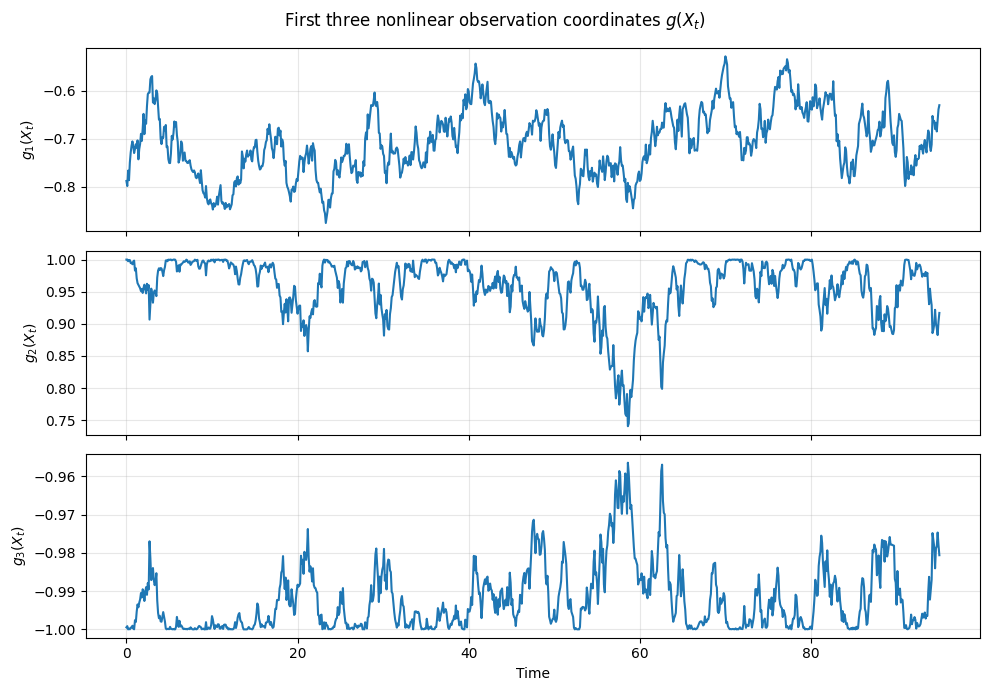

In [112]:
G = obs_dict_00["Gclean"]
t = np.arange(len(G)) * gap * dt

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

for j in range(3):
    axes[j].plot(t, G[:, j])
    axes[j].set_ylabel(rf"$g_{j+1}(X_t)$")
    axes[j].grid(True, alpha=0.3)

axes[-1].set_xlabel("Time")
fig.suptitle(r"First three nonlinear observation coordinates $g(X_t)$")
plt.tight_layout()
plt.show()

### Comparing the OU process to the first three coordinates of $g(X_t)$
Note that these are not the real observations because we are not plotting with noise

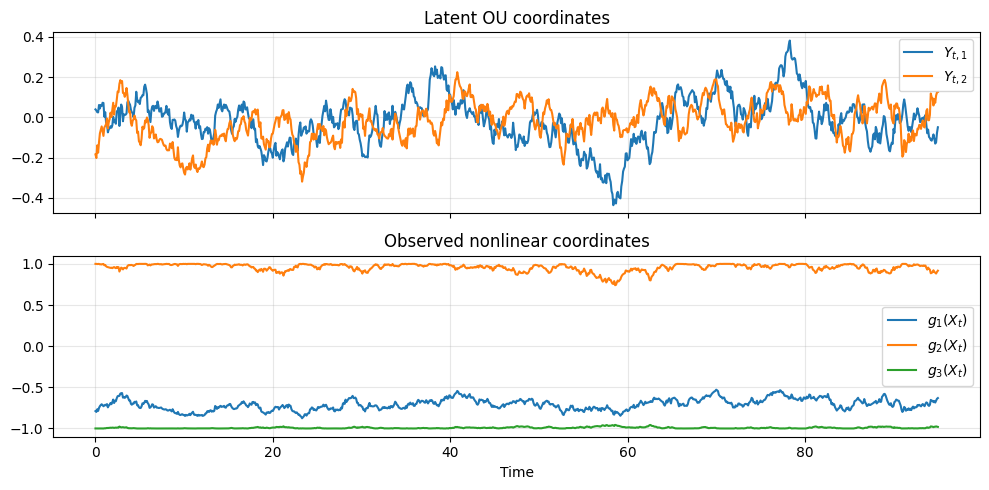

In [113]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

axes[0].plot(t, Y_geom[:, 0], label=r"$Y_{t,1}$")
axes[0].plot(t, Y_geom[:, 1], label=r"$Y_{t,2}$")
axes[0].set_title("Latent OU coordinates")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, G[:, 0], label=r"$g_1(X_t)$")
axes[1].plot(t, G[:, 1], label=r"$g_2(X_t)$")
axes[1].plot(t, G[:, 2], label=r"$g_3(X_t)$")
axes[1].set_title("Observed nonlinear coordinates")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

### Reporting some metrics on the robustness grid

In [111]:
rows = []

for D in Ds:
    for sigma in sigma_etas:
        obs = embed_with_noise(X_geom, W, b, D, eta, sigma)
        G = obs["Gclean"]
        Z = obs["Zobs"]

        rows.append({
            "D": D,
            "sigma_eta": sigma,
            "n_points": len(X_geom),
            "Gclean_mean": G.mean(),
            "Gclean_std": G.std(),
            "Zobs_mean": Z.mean(),
            "Zobs_std": Z.std()
        })

results_table = pd.DataFrame(rows)
results_table

,D,sigma_eta,n_points,Gclean_mean,Gclean_std,Zobs_mean,Zobs_std
0,50,0.00,951,0.120754,0.72139,0.120754,0.721390
1,50,0.05,951,0.120754,0.72139,0.120687,0.723052
2,50,0.10,951,0.120754,0.72139,0.120620,0.728130
3,50,0.20,951,0.120754,0.72139,0.120485,0.748214
4,100,0.00,951,0.072680,0.70859,0.072680,0.708590
5,100,0.05,951,0.072680,0.70859,0.072588,0.710279
6,100,0.10,951,0.072680,0.70859,0.072496,0.715461
7,100,0.20,951,0.072680,0.70859,0.072312,0.735963


We can see that we are using the same $g(X_t)$ for all trials. We also see that the observation mean is constant accross all trials, with only the standard deviation increasing, this is a result of using the same noise matrix and it is what we want to see.

# <span style="color:red"> STOPPED HERE

# 2.3.  Recovery of the latent state via diffusion map
Finding the optimal bandwidth with the Coifman, Lafon rule

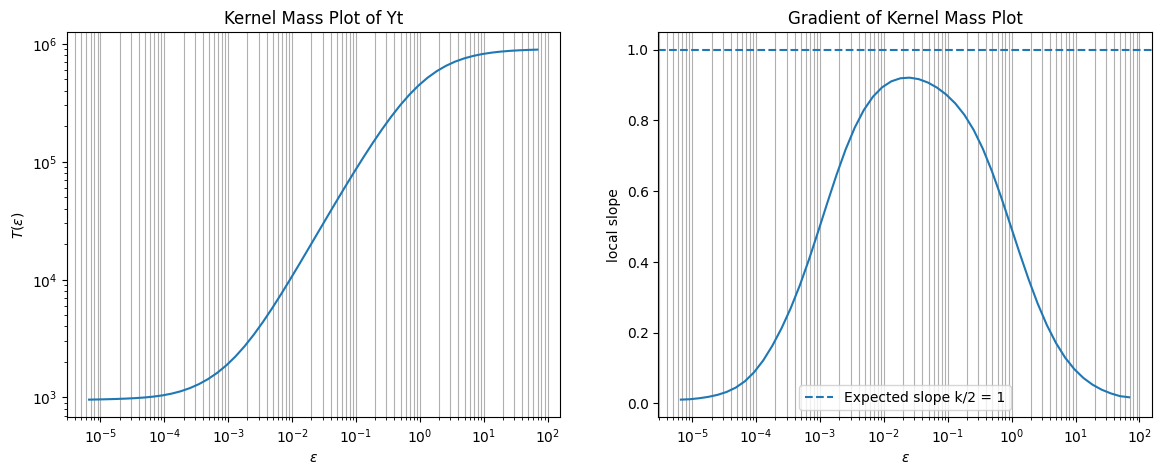

In [99]:
def kernel_mass(D, eps_grid):
    '''
    Returns a list of kernel masses for each bandwidth epsilon
    given a distance matrix and an array of bandwidths

    args:
        D: matrix of squared distances Dij = ||xi - xj||^2
        eps_grid: array of bandwidth values
    returns:
        T_eps: List of kernel masses for each bandwidth
    '''

    n = D.shape[0]
    T_eps = []
    T_off_eps = []

    for epsilon in eps_grid:
        T = np.sum(np.exp(-D / epsilon))
        T_eps.append(T)
        # Diagonal entries only add 1*n, so T_off is T-n
        T_off_eps.append(T - n)
        
    return T_eps, T_off_eps

def plot_kernel_mass(X, title="Kernel Mass Plot", plot=True, ax=None):
    # Calculate squared distances between xi xj
    d = sp.spatial.distance.pdist(X)**2
    D = sp.spatial.distance.squareform(d)

    ### FIX: Found median of minimal distance of each row
    ### this is used to set the lower end of the grid
    D_no_diag = D.copy()
    np.fill_diagonal(D_no_diag, np.inf)

    d_min = np.median(np.min(D_no_diag, axis=1))
    d_med = np.median(d)

    eps_grid = np.logspace(
        np.log10(d_min) - 2,
        np.log10(d_med) + 2,
        50
    )

    T_eps, T_off_eps = kernel_mass(D, eps_grid)

    log_eps = np.log(eps_grid)
    log_T = np.log(T_eps)
    slope = np.gradient(log_T, log_eps)

    if plot:
        if ax is not None:
            ax.loglog(eps_grid, T_eps)
            #ax.loglog(eps_grid, T_off_eps)
            ax.set_title(title)
            ax.set_xlabel(r"$\varepsilon$")
            ax.set_ylabel(r"$T(\varepsilon)$")
            ax.legend()
        else:
            fig, (ax1, ax2) = plt.subplots(1,2)
            # Plotting the kernel mass plot
            ax1.loglog(eps_grid, T_eps)
            ax1.set_title(title)
            ax1.set_xlabel(r"$\varepsilon$")
            ax1.set_ylabel(r"$T(\varepsilon)$")
            ax1.grid(True, axis='x', which='both', ls='-')
            # Plotting the gradient
            ax2.semilogx(eps_grid, slope)
            ax2.axhline(1, linestyle="--", label="Expected slope k/2 = 1")
            ax2.set_xlabel(r"$\varepsilon$")
            ax2.set_ylabel("local slope")
            ax2.set_title("Gradient of Kernel Mass Plot")
            ax2.grid(True, axis='x', which='both', ls='-')
            fig.set_figheight(5)
            fig.set_figwidth(14)
            plt.legend()
            plt.show()

yt = obs_dict_00["Zobs"]
plot_kernel_mass(yt, title="Kernel Mass Plot of Yt")

The linear region looks to be for $\varepsilon \in [0.01, 0.06]$, I will check below

In [100]:
def log_polyfit(x, y, deg=1):
    '''
    Returns the gradient and intercept of the linear 
    approximation of (log(x), log(y))
    '''
    log_x = np.log10(x)
    log_y = np.log10(y)

    m, c = np.polyfit(log_x, log_y, deg=deg)

    return m, c

# region of epsilon grid for linear behaviour
eps_grid = np.logspace(np.log10(0.01), np.log10(0.06), 40)
# Computing the kernel mass for this region
d = sp.spatial.distance.pdist(yt)**2
D = sp.spatial.distance.squareform(d)
T_eps, T_off_eps = kernel_mass(D, eps_grid)
# Computing the slope of the linear region
m_sr, c_sr = log_polyfit(eps_grid, T_eps)
print(f'Linear regime Gradient for embedded data: {m_sr:.2f}')

Linear regime Gradient for embedded data: 0.92


This is not correct if the intrinsic dimension is 2. Maybe this is due to the nosie?  

I got rid of the noise and the gradient never reached 1, how does this make sense?

The X coordinates themselves don't even give a gradient of 1.

I will carry on by choosing $\varepsilon^\star=0.145$

### Using the embedding function from diffusion.ipynb

In [ ]:
def embedding_real(X, epsilon=None, alpha=1, k=2):
    # Distance matrix
    d = sp.spatial.distance.pdist(X)
    D = sp.spatial.distance.squareform(d) ** 2

    # Gaussian affinity matrix
    if epsilon is None:
        epsilon = np.mean(D)
    W = np.exp(-D / epsilon)

    # Normalised affinity matrix
    q = np.sum(W, axis=1)
    W_a = W / np.outer(np.power(q, alpha), np.power(q, alpha))

    # Transition Matrix
    P = W_a / np.sum(W_a, axis=1, keepdims=True)

    # Compute eigenvalues of S which is related to P and symmetric
    d_alpha = np.sum(W_a, axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(d_alpha))
    S = D_inv_sqrt @ W_a @ D_inv_sqrt

    # symmetric eigendecomposition (real)
    n = S.shape[0]
    if n <= 5000:
        w, v = np.linalg.eigh(S)
    else:
        w, v = sp.sparse.linalg.eigsh(S)
    
    idx = np.argsort(w)[::-1]
    w = w[idx]
    v = v[:, idx]
    # right eigenvectors of P: phi = D^{-1/2} v
    phi = D_inv_sqrt @ v

   
    phi_k = phi[:, 1:k+1]      # skip trivial first eigenvector
    lambda_k = w[1:k+1]

    # diffusion coordinates (t = 1)
    Psi = phi_k * lambda_k      # columns scaled by eigenvalues

    res = {
        "X": X,
        "epsilon": epsilon,
        "alpha": alpha,
        "raw_degrees": q,
        "normalised_degrees": d_alpha,
        "markov_evals": w,
        "right_eigenvectors": phi,
        "diff_coordinates": Psi,
        "transition_matrix": P
    }
    return res

In [ ]:
# Choosing k=4 means that I can see results for
# k = 1, ..., 4 without rerunning the function
obs_dm = embedding_real(yt, epsilon=EPS, alpha=1, k=4, eigen=True)

w = w[1:]

gaps = w[:-1] - w[1:]

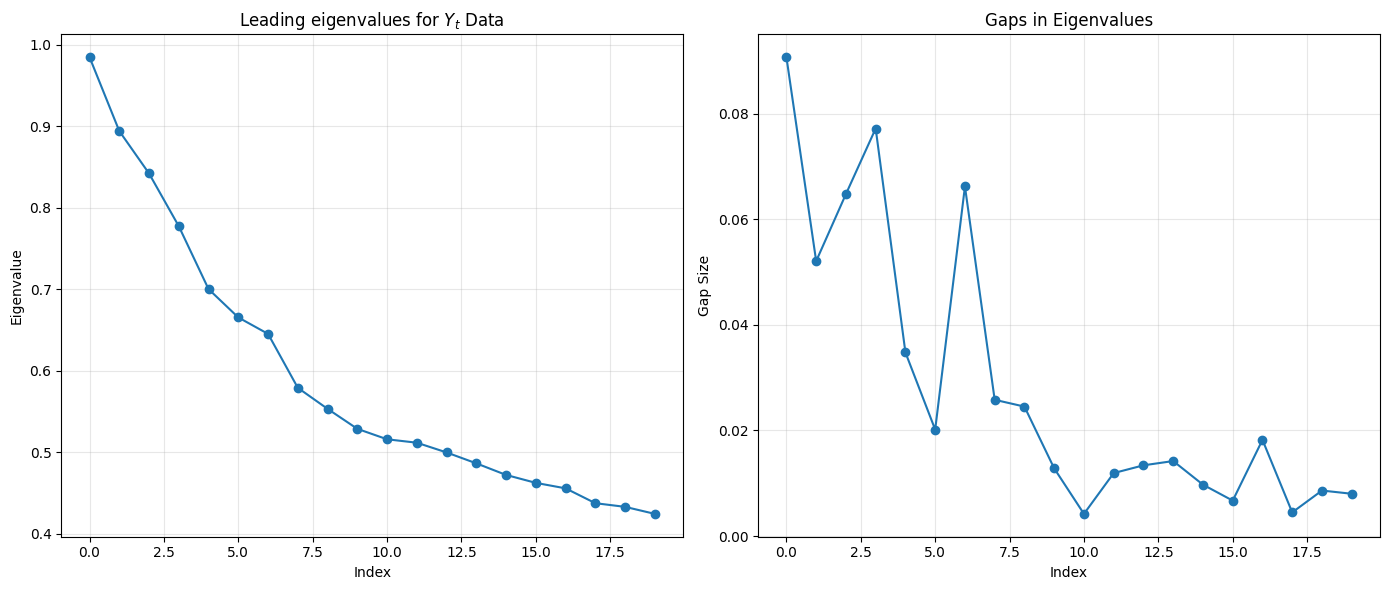

In [181]:
fig, (ax1, ax2) = plt.subplots(1,2)
fig.set_figheight(6)
fig.set_figwidth(14)

ax1.plot(w[:20], marker='o')
ax1.set_title('Leading eigenvalues for $Y_t$ Data')
ax1.set_xlabel('Index')
ax1.set_ylabel('Eigenvalue')
ax1.grid(True, alpha=0.3)

ax2.plot(gaps[:20], marker='o')
ax2.set_title('Gaps in Eigenvalues')
ax2.set_xlabel('Index')
ax2.set_ylabel('Gap Size')
ax2.grid(True, alpha=0.3)

plt.tight_layout()

This would suggest that $k=1$. Most of the time, for different $X$, the eigenvalues suggest that $k>2$.

For the first generation of $y_t$ for this specific datacloud $X$, I found $k=2$ with the spectral analysis. However, since then all the generations of $y_t$ (with the same $X$) have given $k=1$.

The intrinsic dimension estimate with spectral analysis are very dependent on the noise in each step of the process to create $y_t$.

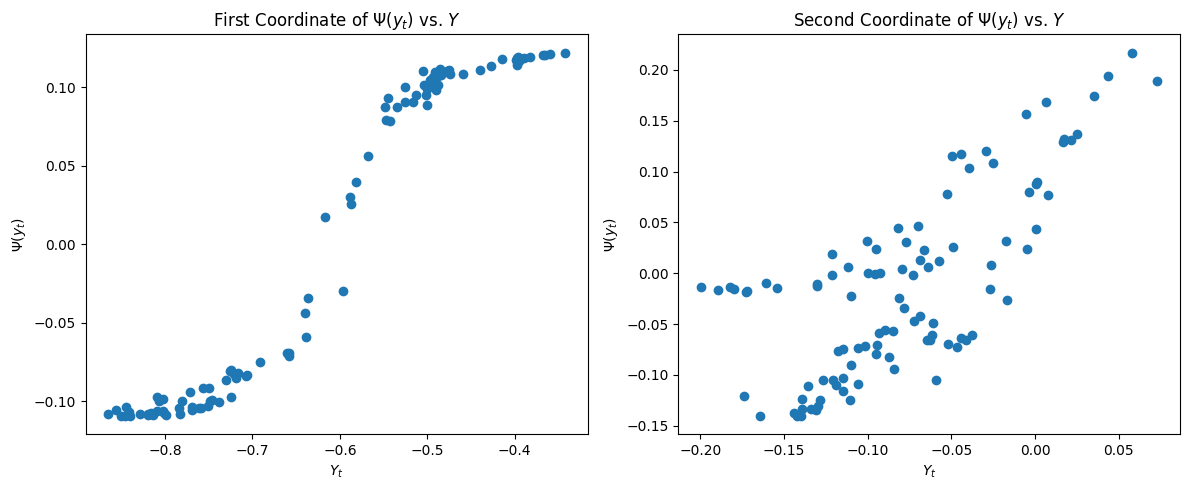

In [183]:
fig, (ax1, ax2) = plt.subplots(1,2)
fig.set_figheight(5)
fig.set_figwidth(12)

ax1.scatter(Y[:,0], Psi_Y[:,0])
ax1.set_title(r"First Coordinate of $\Psi(y_t)$ vs. $Y$")
ax1.set_xlabel(r"$Y_t$")
ax1.set_ylabel(r"$\Psi(y_t)$")

ax2.scatter(Y[:,1], Psi_Y[:,1])
ax2.set_title(r"Second Coordinate of $\Psi(y_t)$ vs. $Y$")
ax2.set_xlabel(r"$Y_t$")
ax2.set_ylabel(r"$\Psi(y_t)$")


plt.tight_layout()
plt.show()

### Fitting Procrustes alignment

In [184]:
Y_proc, Psi_proc, disparity = procrustes(Y, Psi_Y[:, :2])
print(f'Residual error: {disparity}')

Residual error: 0.2667537144725588


I have not worked through this all properly. I am experimenting with changing the parameters in the OU process. That changes things a lot, but not entierly sure why. Some OU paths stay in a line on the sphere rather than exploring the 2 dimensions of the sphere, this makes a big difference to the plots in the validation section of 2.3

# 2.4 Maximum likelihood estimation of the OU parameters

In [186]:
# Procrustes-aligned 
Y_tilde = Psi_proc

# Residuals
r = Y_tilde[1:] - np.exp(-kappa*dt)*Y_tilde[:-1]

# We want the residuals to have zero mean and cov = sig^2/2kappa (1-e^2kappa dt)I_2
# 



### Plotting same stuff for different $X$ to see how it changes

In [146]:
def plot_3d_points(X):

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    pts = np.column_stack((X[:, 0], X[:, 2], X[:, 1]))
    cmap = plt.cm.viridis
    norm = plt.Normalize(0, len(pts) - 2)

    for i in range(len(pts) - 1):
        ax.plot(
            pts[i:i+2, 0],
            pts[i:i+2, 1],
            pts[i:i+2, 2],
            color=cmap(norm(i)),
            linewidth=2,
        )
    ax.scatter(X[:, 0], X[:, 2], X[:, 1], s=20)
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    ax.set_title('Coordinates X on S2 in R3')
    ax.view_init(elev=20, azim=60)
    plt.show()

def plot_eigenvalues(w):
    '''
    Given eigenvalues, plot the first 20 non-trivial ones
    and plot the corresponding gaps between them
    '''
    w = w[1:]
    gaps = w[:-1] - w[1:]

    fig, (ax1, ax2) = plt.subplots(1,2)
    fig.set_figheight(6)
    fig.set_figwidth(14)

    ax1.plot(w[:20], marker='o')
    ax1.set_title('Leading eigenvalues for $Y_t$ Data')
    ax1.set_xlabel('Index')
    ax1.set_ylabel('Eigenvalue')
    ax1.grid(True, alpha=0.3)

    ax2.plot(gaps[:20], marker='o')
    ax2.set_title('Gaps in Eigenvalues')
    ax2.set_xlabel('Index')
    ax2.set_ylabel('Gap Size')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()


def plot_psi_vs_y(Y, Psi_Y):
    '''
    Plot the relationship between Psi(yt) and Yt for each coordinate
    '''

    fig, (ax1, ax2) = plt.subplots(1,2)
    fig.set_figheight(5)
    fig.set_figwidth(12)

    ax1.scatter(Y[:,0], Psi_Y[:,0])
    ax1.set_title(r"First Coordinate of $\Psi(y_t)$ vs. $Y$")
    ax1.set_xlabel(r"$Y_t$")
    ax1.set_ylabel(r"$\Psi(y_t)$")

    ax2.scatter(Y[:,1], Psi_Y[:,1])
    ax2.set_title(r"Second Coordinate of $\Psi(y_t)$ vs. $Y$")
    ax2.set_xlabel(r"$Y_t$")
    ax2.set_ylabel(r"$\Psi(y_t)$")


    plt.tight_layout()
    plt.show()

D = 100, $\sigma_\eta=0.05$

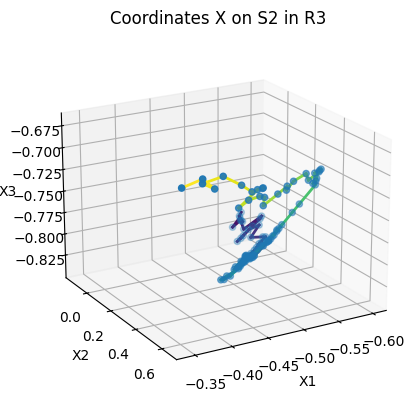

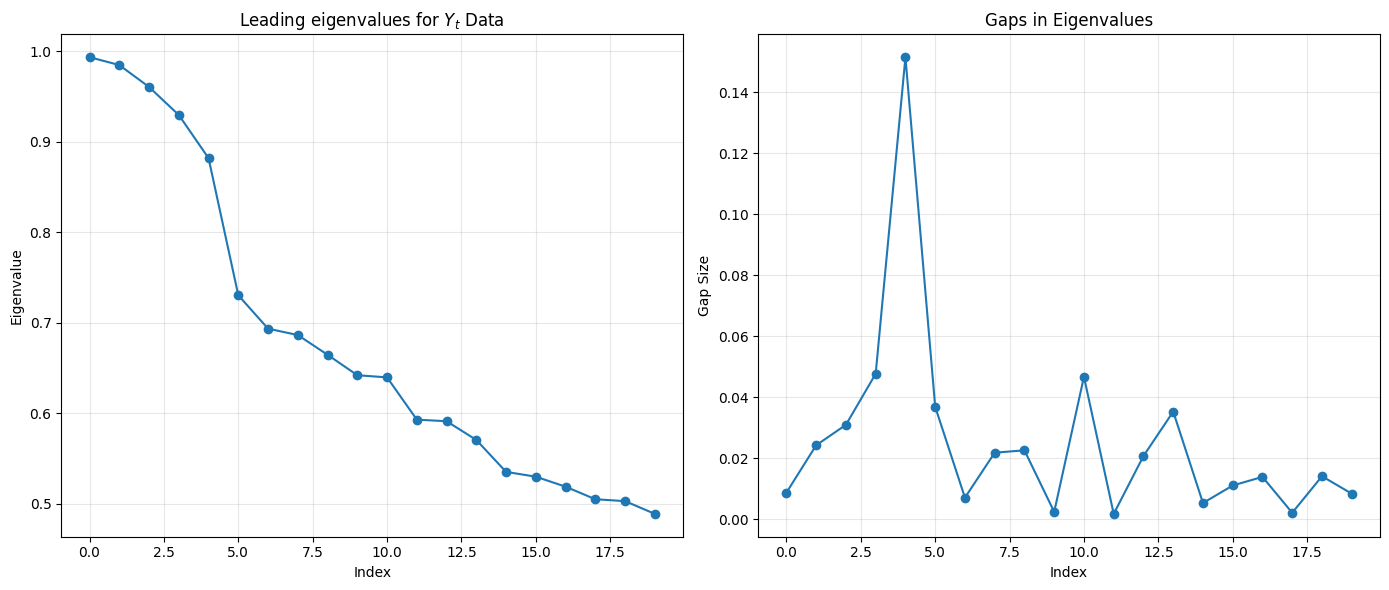

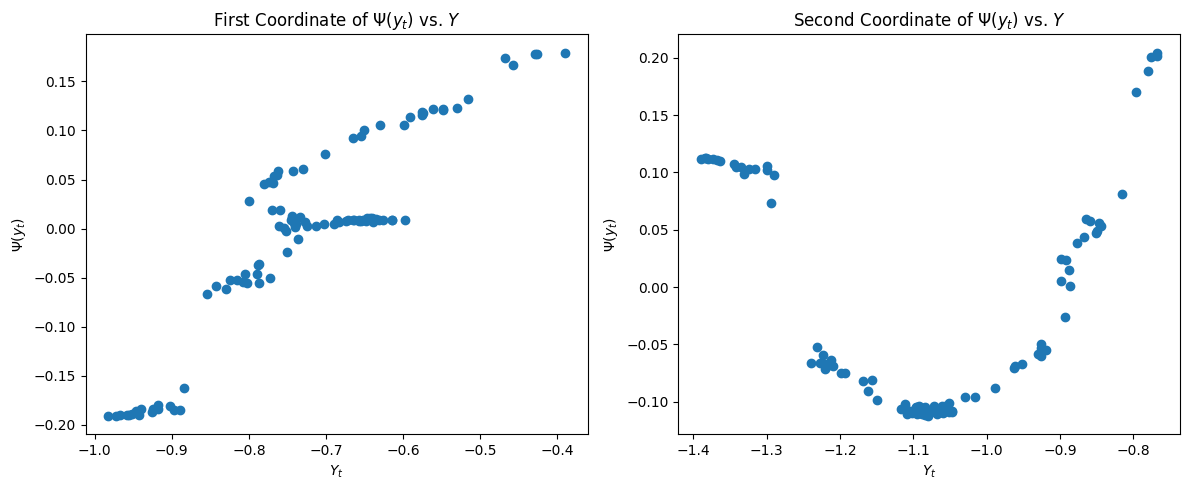

Residual error: 0.5049478935062884


In [161]:
X, Y = simulate_ou_on_sphere()
yt = embed_with_noise(X, D=100, sigma_eta=0.05)
eps = plot_kernel_mass(yt, r"D=100, $\sigma_\mu=0.1$", plot=False)
Psi_Y, w, v = embedding(yt, epsilon=eps, alpha=1, k=4, eigen=True)

plot_3d_points(X)
plot_eigenvalues(w)
plot_psi_vs_y(Y, Psi_Y)
Y_proc, Psi_proc, disparity = procrustes(Y, Psi_Y[:, :2])
print(f'Residual error: {disparity}')

D = 100, $\sigma_\eta=0.1$

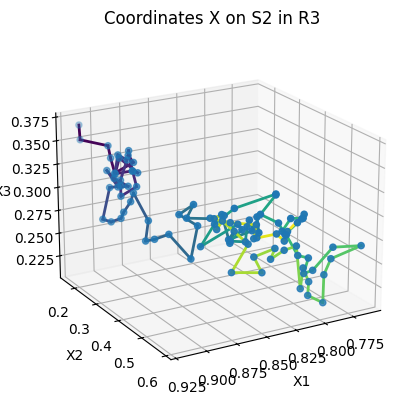

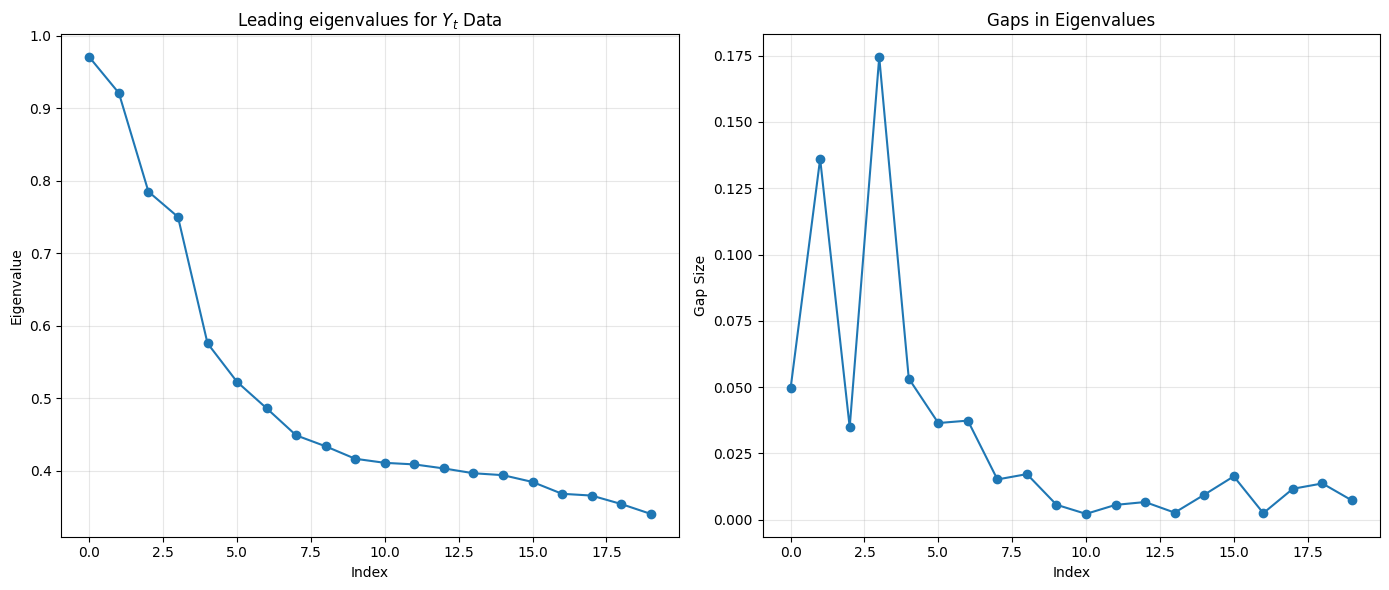

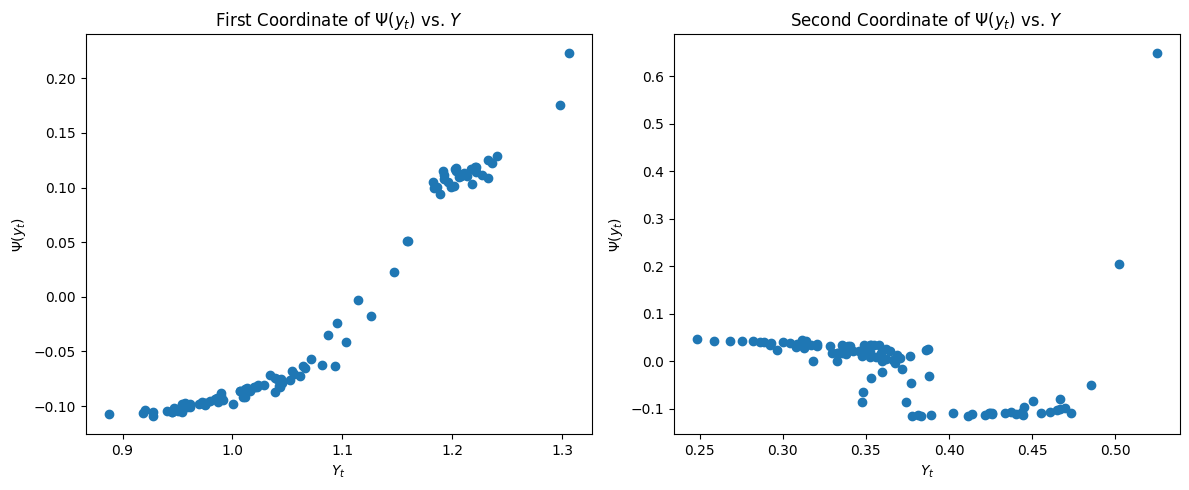

Residual error: 0.4319894045020477


In [162]:
X, Y = simulate_ou_on_sphere()
yt = embed_with_noise(X, D=100, sigma_eta=0.05)
eps = plot_kernel_mass(yt, r"D=100, $\sigma_\mu=0.1$", plot=False)
Psi_Y, w, v = embedding(yt, epsilon=eps, alpha=1, k=4, eigen=True)

plot_3d_points(X)
plot_eigenvalues(w)
plot_psi_vs_y(Y, Psi_Y)
Y_proc, Psi_proc, disparity = procrustes(Y, Psi_Y[:, :2])
print(f'Residual error: {disparity}')

D = 100, $\sigma_\eta=0.2$

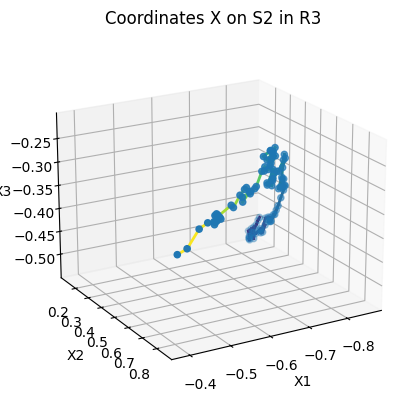

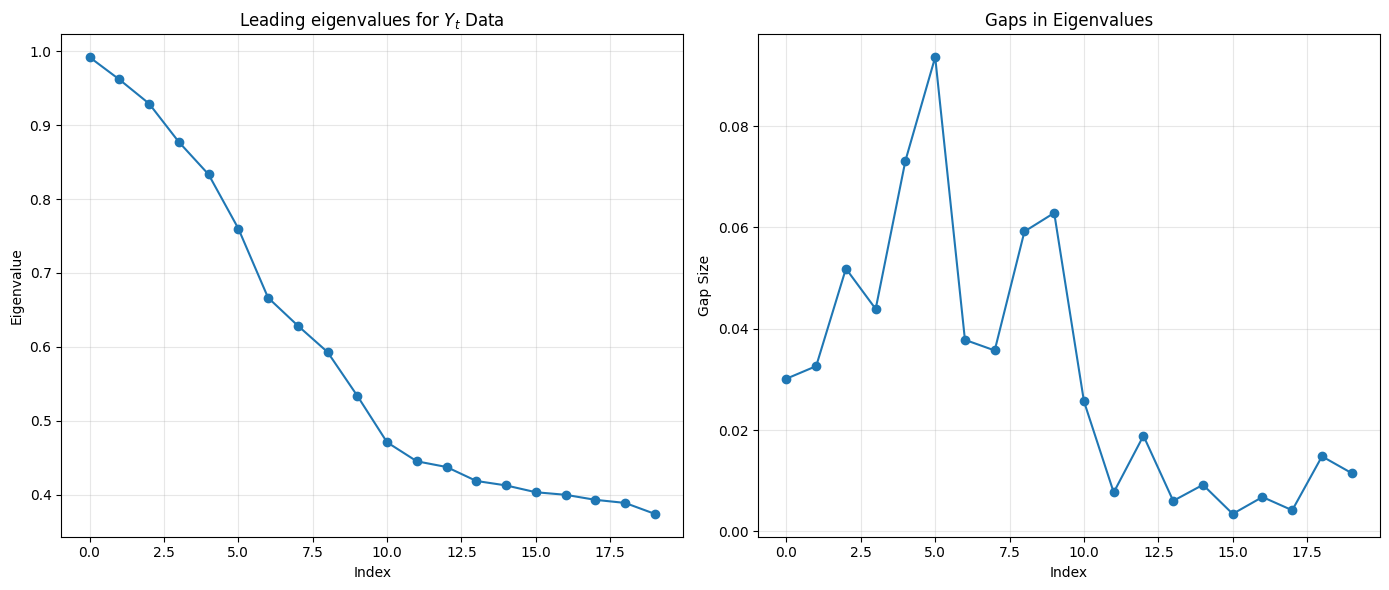

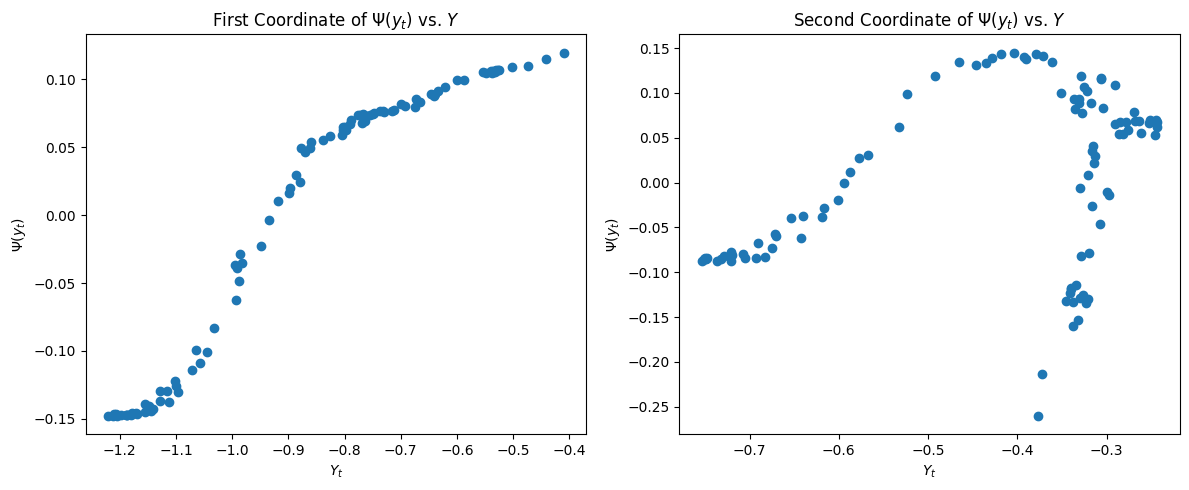

Residual error: 0.2731638439609886


In [163]:
X, Y = simulate_ou_on_sphere()
yt = embed_with_noise(X, D=100, sigma_eta=0.05)
eps = plot_kernel_mass(yt, r"D=100, $\sigma_\mu=0.1$", plot=False)
Psi_Y, w, v = embedding(yt, epsilon=eps, alpha=1, k=4, eigen=True)

plot_3d_points(X)
plot_eigenvalues(w)
plot_psi_vs_y(Y, Psi_Y)
Y_proc, Psi_proc, disparity = procrustes(Y, Psi_Y[:, :2])
print(f'Residual error: {disparity}')

D = 75, $\sigma_\eta=0.05$

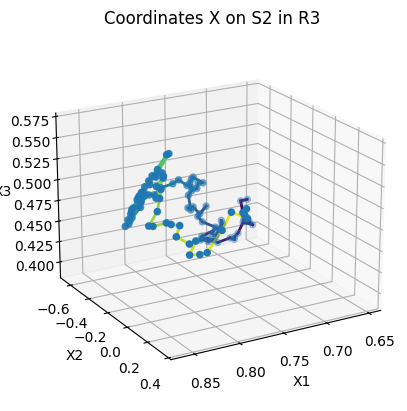

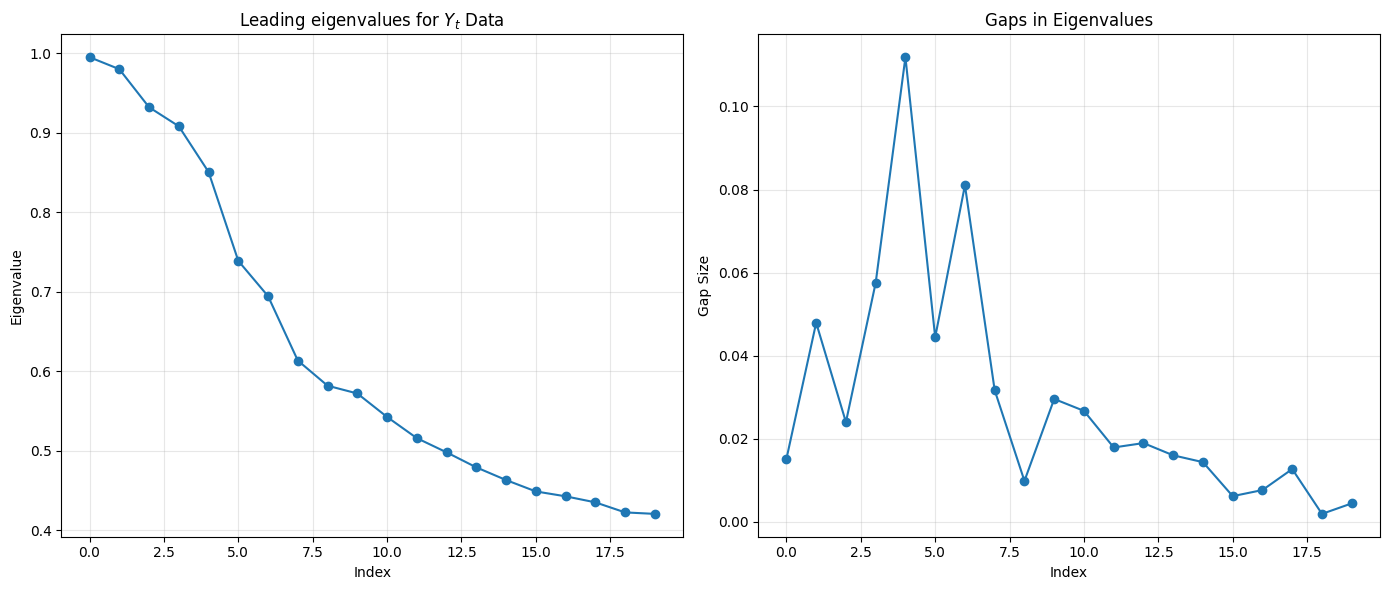

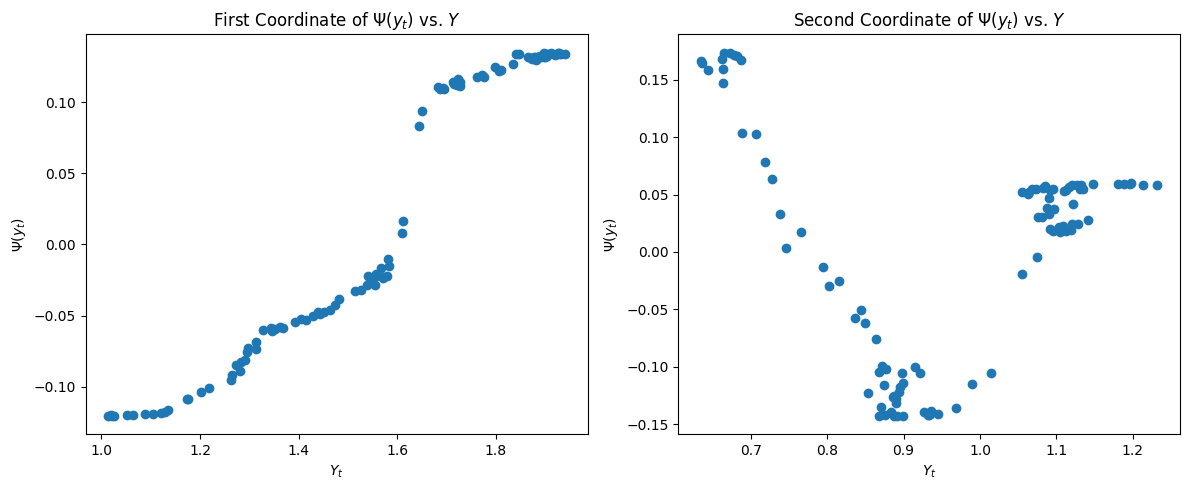

Residual error: 0.533005808952182


In [164]:
X, Y = simulate_ou_on_sphere()
yt = embed_with_noise(X, D=100, sigma_eta=0.05)
eps = plot_kernel_mass(yt, r"D=100, $\sigma_\mu=0.1$", plot=False)
Psi_Y, w, v = embedding(yt, epsilon=eps, alpha=1, k=4, eigen=True)

plot_3d_points(X)
plot_eigenvalues(w)
plot_psi_vs_y(Y, Psi_Y)
Y_proc, Psi_proc, disparity = procrustes(Y, Psi_Y[:, :2])
print(f'Residual error: {disparity}')

D = 75, $\sigma_\mu=0.1$

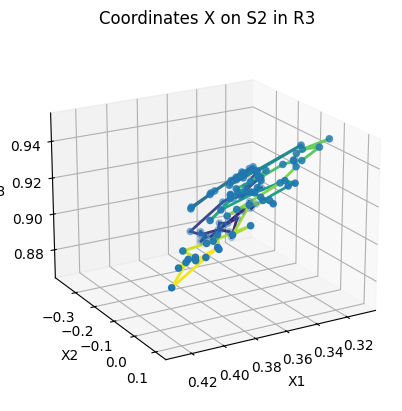

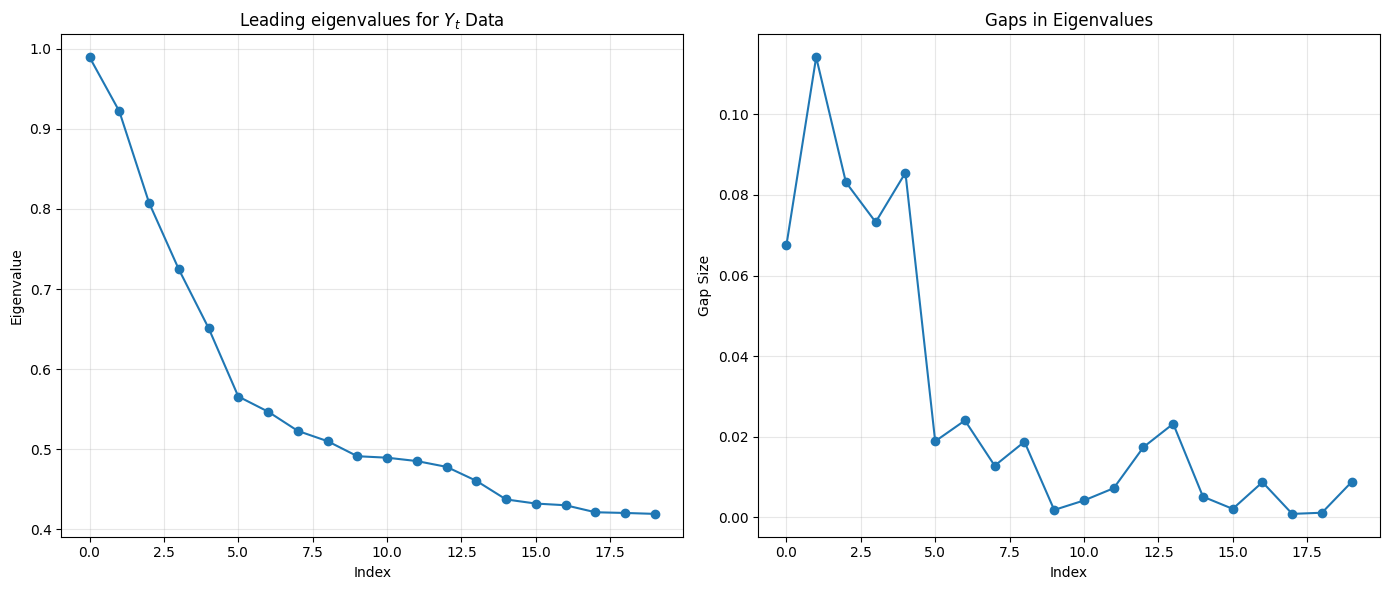

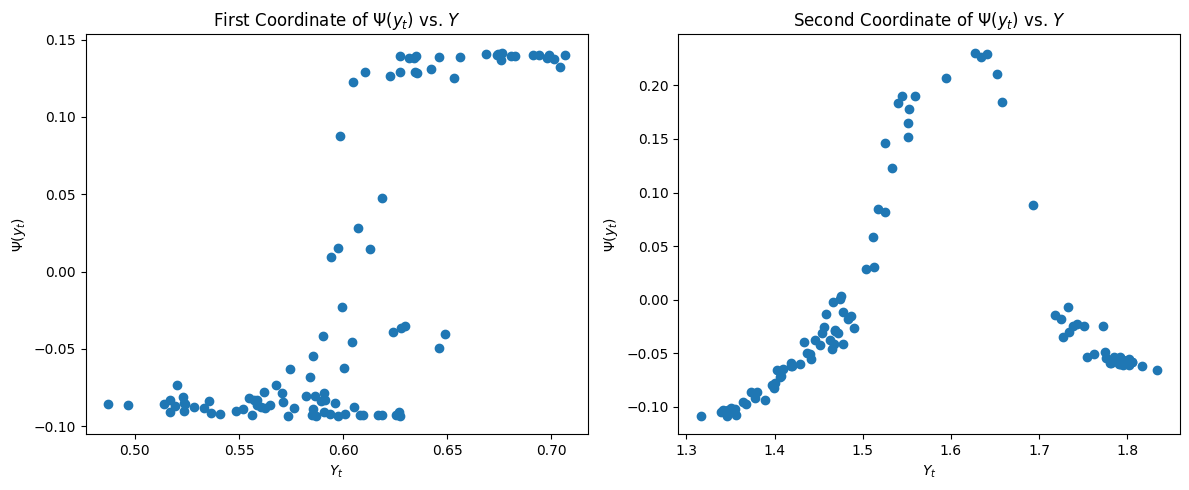

Residual error: 0.4621108865026734


In [165]:
X, Y = simulate_ou_on_sphere()
yt = embed_with_noise(X, D=100, sigma_eta=0.05)
eps = plot_kernel_mass(yt, r"D=100, $\sigma_\mu=0.1$", plot=False)
Psi_Y, w, v = embedding(yt, epsilon=eps, alpha=1, k=4, eigen=True)

plot_3d_points(X)
plot_eigenvalues(w)
plot_psi_vs_y(Y, Psi_Y)
Y_proc, Psi_proc, disparity = procrustes(Y, Psi_Y[:, :2])
print(f'Residual error: {disparity}')

D = 75, $\sigma_\mu=0.2$

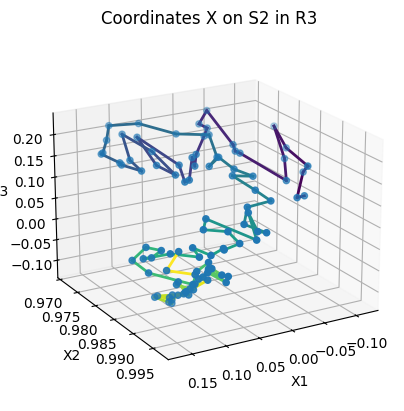

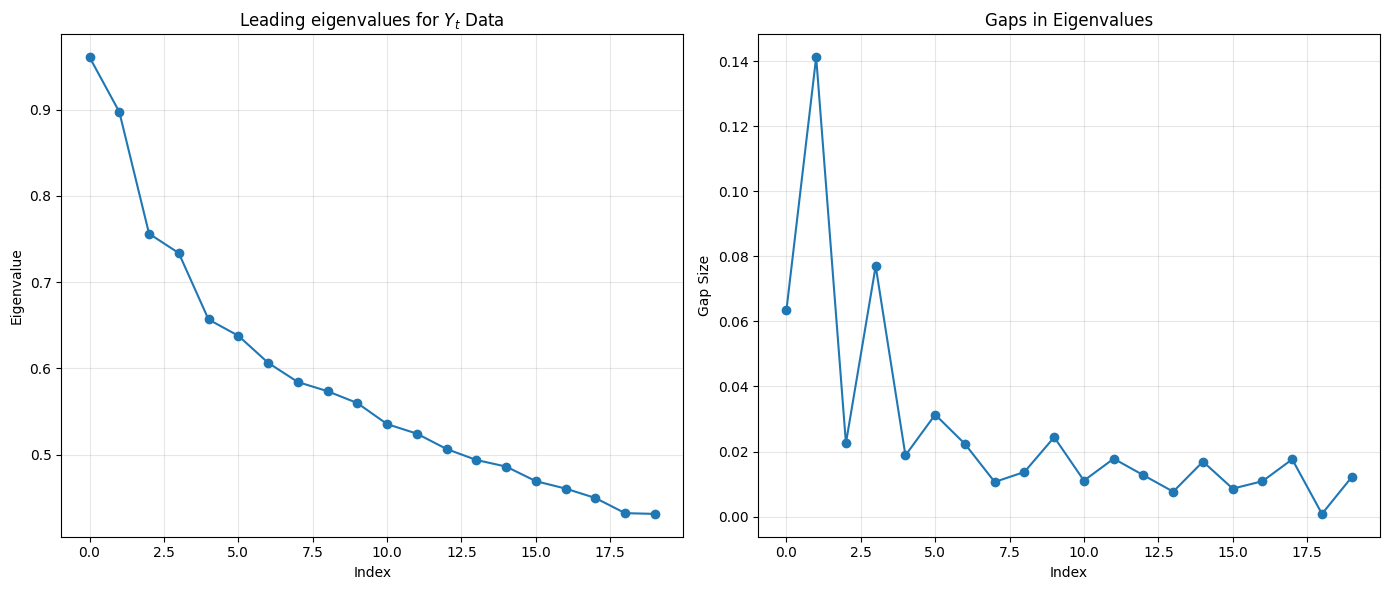

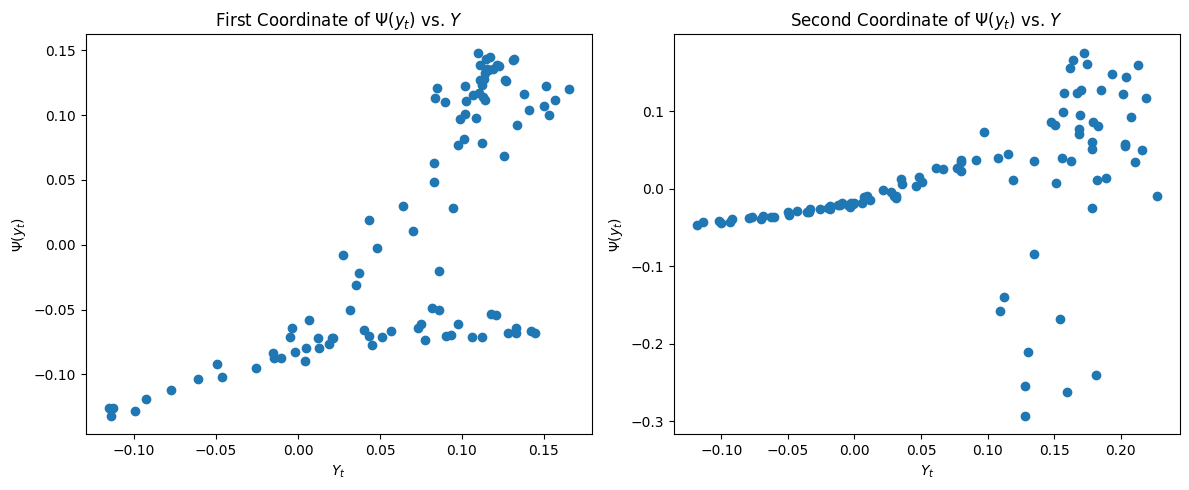

Residual error: 0.16580985201160658


In [166]:
X, Y = simulate_ou_on_sphere()
yt = embed_with_noise(X, D=100, sigma_eta=0.05)
eps = plot_kernel_mass(yt, r"D=100, $\sigma_\mu=0.1$", plot=False)
Psi_Y, w, v = embedding(yt, epsilon=eps, alpha=1, k=4, eigen=True)

plot_3d_points(X)
plot_eigenvalues(w)
plot_psi_vs_y(Y, Psi_Y)
Y_proc, Psi_proc, disparity = procrustes(Y, Psi_Y[:, :2])
print(f'Residual error: {disparity}')